In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Signal generation
def generate_bpsk_signal(num_samples, SNR_dB):
    bits = np.random.randint(0, 2, num_samples)
    symbols = 2 * bits - 1
    noise = (1/np.sqrt(2)) * (np.random.randn(num_samples) + 1j * np.random.randn(num_samples))
    SNR_linear = 10**(SNR_dB / 10.0)
    noise_power = np.var(symbols) / SNR_linear
    noisy_symbols = symbols + np.sqrt(noise_power) * noise
    return noisy_symbols

def generate_qpsk_signal(num_samples, SNR_dB):
    bits = np.random.randint(0, 4, num_samples)
    symbols = np.exp(1j * (np.pi / 4 + np.pi / 2 * bits))
    noise = (1/np.sqrt(2)) * (np.random.randn(num_samples) + 1j * np.random.randn(num_samples))
    SNR_linear = 10**(SNR_dB / 10.0)
    noise_power = np.var(symbols) / SNR_linear
    noisy_symbols = symbols + np.sqrt(noise_power) * noise
    return noisy_symbols

# Feature extraction
def extract_features(signal):
    features = np.vstack((np.real(signal), np.imag(signal))).T
    return features

# Parameters
num_samples = 1000
SNR_dB = 10

# Generate signals
bpsk_signal = generate_bpsk_signal(num_samples, SNR_dB)
qpsk_signal = generate_qpsk_signal(num_samples, SNR_dB)

# Extract features
bpsk_features = extract_features(bpsk_signal)
qpsk_features = extract_features(qpsk_signal)

# Create labels
bpsk_labels = np.zeros(num_samples)
qpsk_labels = np.ones(num_samples)

# Combine data
X = np.vstack((bpsk_features, qpsk_features))
y = np.hstack((bpsk_labels, qpsk_labels))

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# AMC Using KNN

In [2]:
# KNN classification
k=3
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

# Predictions and evaluation
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 93.25%
Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.92      0.93       199
         1.0       0.93      0.94      0.93       201

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.93      0.93      0.93       400



Plot-KNN

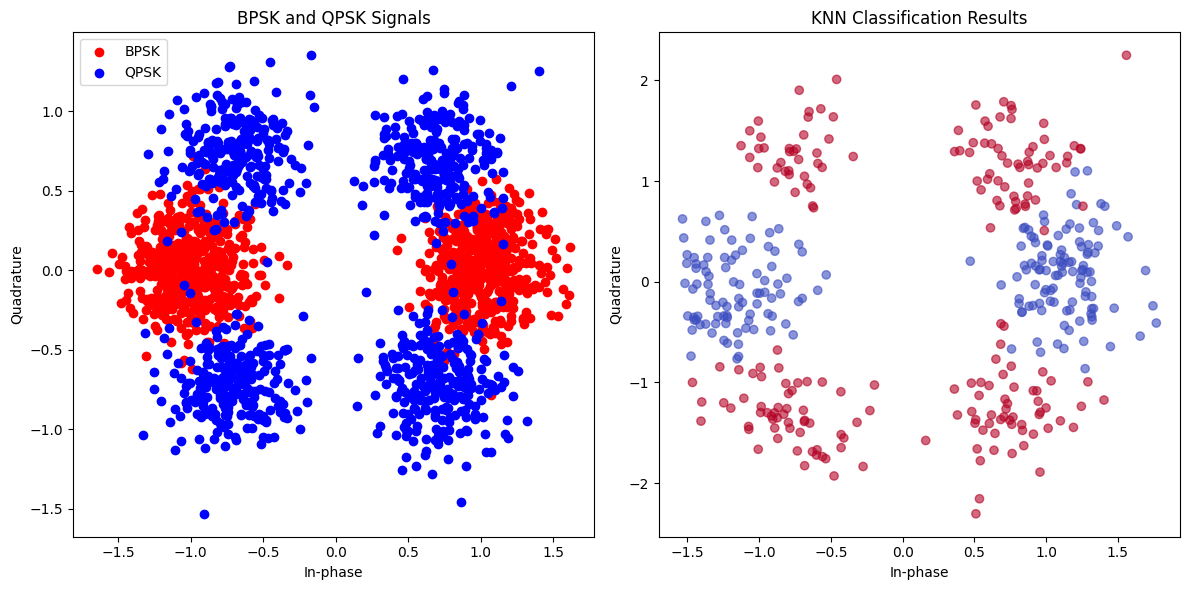

In [3]:
# Plotting
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(bpsk_features[:, 0], bpsk_features[:, 1], color='r', label='BPSK')
plt.scatter(qpsk_features[:, 0], qpsk_features[:, 1], color='b', label='QPSK')
plt.title("BPSK and QPSK Signals")
plt.xlabel("In-phase")
plt.ylabel("Quadrature")
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, cmap='coolwarm', alpha=0.6)
plt.title("KNN Classification Results")
plt.xlabel("In-phase")
plt.ylabel("Quadrature")

plt.tight_layout()
plt.show()

# AMC Using LOGISTIC REGRESSION

In [4]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("\nLogistic Regression Results")
print(f"Accuracy: {accuracy_lr * 100:.2f}%")
print(classification_report(y_test, y_pred_lr))


Logistic Regression Results
Accuracy: 44.50%
              precision    recall  f1-score   support

         0.0       0.45      0.55      0.50       199
         1.0       0.43      0.34      0.38       201

    accuracy                           0.45       400
   macro avg       0.44      0.45      0.44       400
weighted avg       0.44      0.45      0.44       400



Plot- LR

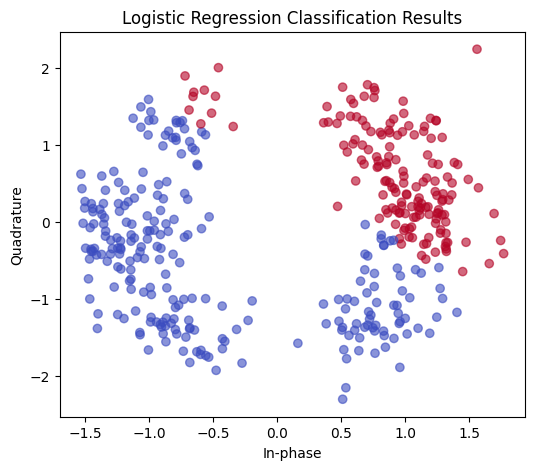

In [5]:
plt.figure(figsize=(6, 5))
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred_lr, cmap='coolwarm', alpha=0.6)
plt.title("Logistic Regression Classification Results")
plt.xlabel("In-phase")
plt.ylabel("Quadrature")
plt.show()

# AMC Using Linear SVM

In [6]:
from sklearn.svm import SVC

# Linear SVM
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)

y_pred_svm_linear = svm_linear.predict(X_test)
accuracy_svm_linear = accuracy_score(y_test, y_pred_svm_linear)

print("\nLinear SVM Results")
print(f"Accuracy: {accuracy_svm_linear * 100:.2f}%")
print(classification_report(y_test, y_pred_svm_linear))


Linear SVM Results
Accuracy: 58.00%
              precision    recall  f1-score   support

         0.0       0.56      0.74      0.64       199
         1.0       0.62      0.42      0.50       201

    accuracy                           0.58       400
   macro avg       0.59      0.58      0.57       400
weighted avg       0.59      0.58      0.57       400



Plot-SVM

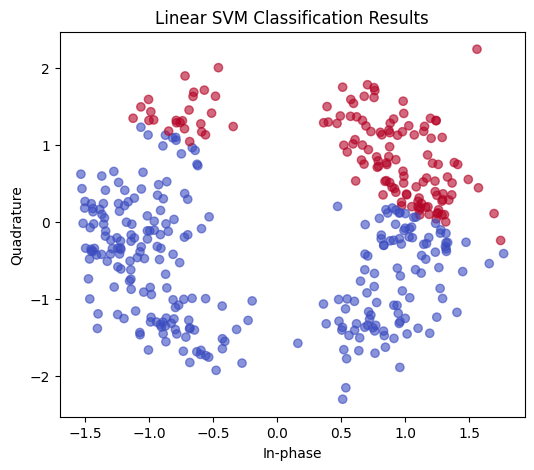

In [7]:
plt.figure(figsize=(6, 5))
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred_svm_linear, cmap='coolwarm', alpha=0.6)
plt.title("Linear SVM Classification Results")
plt.xlabel("In-phase")
plt.ylabel("Quadrature")
plt.show()

# AMC Using Kernel SVM

In [8]:
# Kernel SVM (RBF)
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train, y_train)

y_pred_svm_rbf = svm_rbf.predict(X_test)
accuracy_svm_rbf = accuracy_score(y_test, y_pred_svm_rbf)

print("\nKernel SVM (RBF) Results")
print(f"Accuracy: {accuracy_svm_rbf * 100:.2f}%")
print(classification_report(y_test, y_pred_svm_rbf))


Kernel SVM (RBF) Results
Accuracy: 94.25%
              precision    recall  f1-score   support

         0.0       0.94      0.94      0.94       199
         1.0       0.94      0.94      0.94       201

    accuracy                           0.94       400
   macro avg       0.94      0.94      0.94       400
weighted avg       0.94      0.94      0.94       400



Plot-Kenel SVM

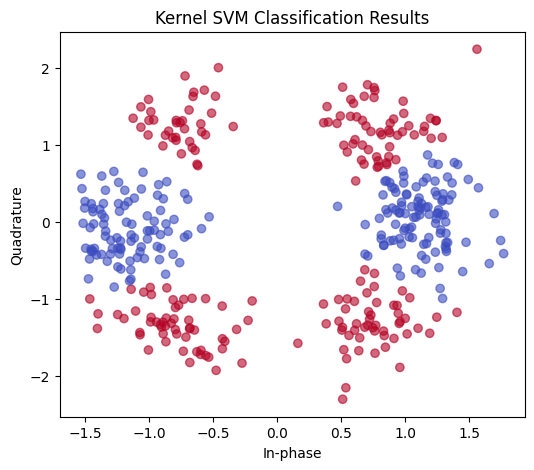

In [9]:
plt.figure(figsize=(6, 5))
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred_svm_rbf, cmap='coolwarm', alpha=0.6)
plt.title("Kernel SVM Classification Results")
plt.xlabel("In-phase")
plt.ylabel("Quadrature")
plt.show()

# OBSERVATIONS



In this experiment, BPSK and QPSK signals were classified using Logistic Regression, Linear SVM, KNN, and Kernel SVM, with only the in-phase and quadrature components of each received symbol used as features.

The results indicated that Logistic Regression-44.50% and Linear SVM-58.00% achieved accuracy close to random guessing. This is because both methods rely on a linear decision boundary, and the BPSK and QPSK constellation points are not linearly separable in the IQ plane. A single straight line cannot effectively distinguish between the two modulation schemes.

In contrast, KNN-93.25% and Kernel SVM-94.25% achieved much higher accuracy. These models are capable of forming nonlinear decision boundaries, allowing them to better capture the structure of the constellation clusters. Therefore, nonlinear classifiers are more effective for Automatic modulation classification of BPSK and QPSK.
